# ⭐ 1. Data Understanding & Cleaning

# First import the libraries.

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset.

In [4]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


# How many matches are played in total?

In [10]:
count_match= df['match_id'].count()
print(f"There are {count_match} matches played in total" )

There are 74 matches played in total


# Show the information of the dataset.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

# Are there missing values?

In [14]:
df.isnull().sum().to_frame()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


# 📊 2. Team Performance Analysis

# Which team has won the most matches?

In [16]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


In [28]:
most_win = df['match_winner'].value_counts()

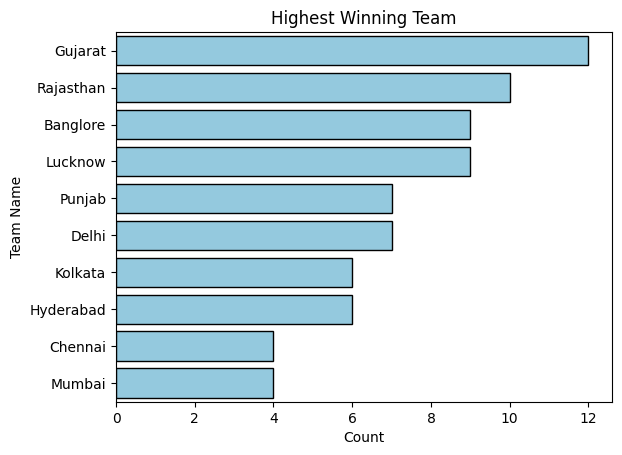

In [143]:
sns.barplot( y = most_win.index,
             x = most_win.values,
             edgecolor ='black',
             color ='skyblue'
)
plt.title('Highest Winning Team')
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# What is each team's win percentage?

In [100]:
win = df['match_winner'].value_counts()
percentage = (win*100)/df.shape[0]
percentage.round(2).reset_index(name ='percentage (%)')


,match_winner,percentage (%)
0,Gujarat,16.22
1,Rajasthan,13.51
2,Banglore,12.16
3,Lucknow,12.16
4,Punjab,9.46
5,Delhi,9.46
6,Kolkata,8.11
7,Hyderabad,8.11
8,Chennai,5.41
9,Mumbai,5.41


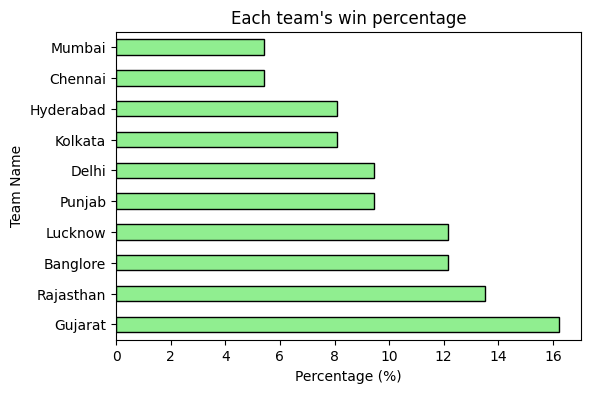

In [103]:
plt.figure(figsize=(6,4))

percentage.plot(kind = 'barh', color='lightgreen',edgecolor='black')
plt.title("Each team's win percentage")
plt.xlabel('Percentage (%)')
plt.ylabel('Team Name')
plt.show()

# Which team performs better while batting first vs chasing?

In [140]:
team_order = df['match_winner'].value_counts().index

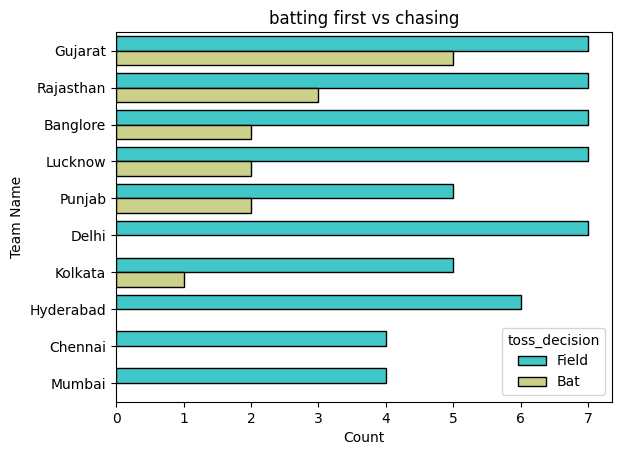

In [142]:
sns.countplot(y ='match_winner',
              data= df,
              hue ='toss_decision',
              palette ='rainbow',
              edgecolor = 'black',
              order = team_order
)
plt.title('batting first vs chasing')
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# Matches played by each team.

In [84]:
all_teams = pd.concat([df['team1'], df['team2']])
matches_played = all_teams.value_counts()

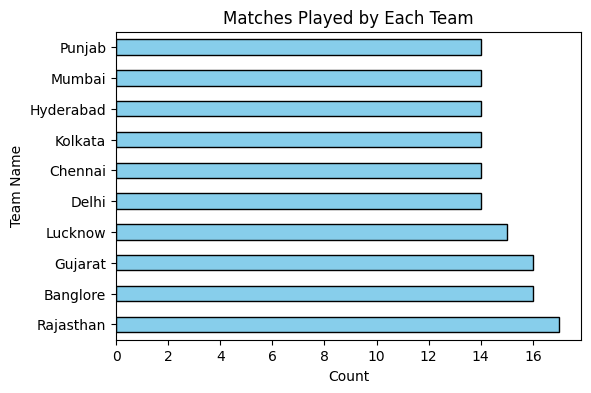

In [107]:
plt.figure(figsize=(6,4))

matches_played.plot(kind ='barh', color ='skyblue',edgecolor='black')
plt.title('Matches Played by Each Team')
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# Which team lost the most matches?

In [115]:
all_teams = pd.concat([df['team1'], df['team2']])

matches_played = all_teams.value_counts()
matches_won = df['match_winner'].value_counts()

matches_lost = matches_played - matches_won
Loser_team = matches_lost.sort_values(ascending= False)

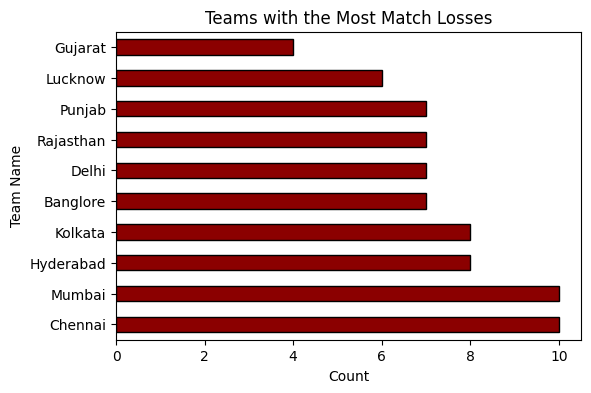

In [120]:
plt.figure(figsize=(6,4))

Loser_team.plot(kind ='barh', color ='darkred',edgecolor='black')
plt.title('Teams with the Most Match Losses')
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# 🔥 3. Toss Analysis

# Which team won the toss most times?

In [122]:
most_times = df['toss_winner'].value_counts()

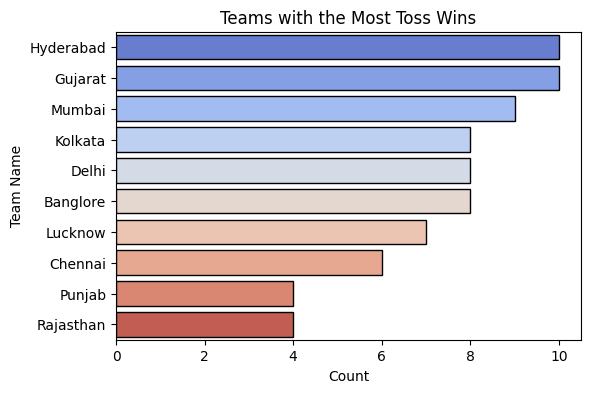

In [132]:
plt.figure(figsize=(6,4))

sns.barplot(y = most_times.index,
            x = most_times.values,
            palette = 'coolwarm',
            edgecolor ='black'
)
plt.title("Teams with the Most Toss Wins")
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# After winning toss, teams choose bat or field more?

In [ ]:
team_order = df['toss_winner'].value_counts().index

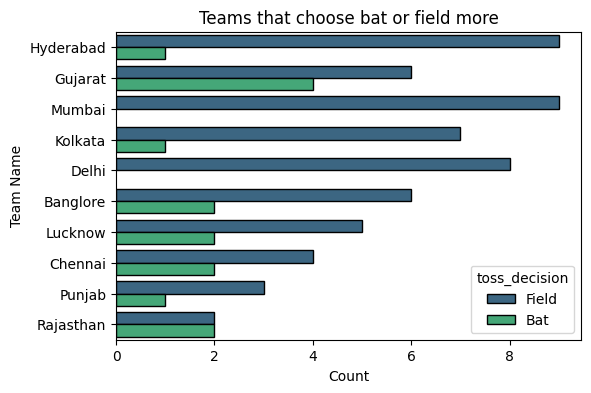

In [139]:
plt.figure(figsize=(6,4))

sns.countplot(y ='toss_winner',
              data = df,
              hue ='toss_decision',
              palette ='viridis',
              edgecolor ='black',
              order = team_order
)
plt.title("Teams that choose bat or field more")
plt.xlabel('Count')
plt.ylabel('Team Name')
plt.show()

# How many matches won after winning toss?

In [157]:
count = df[df['toss_winner']==df['match_winner']]['match_id'].count()
print(f"{count} matches were won by the team that won the toss.")

36 matches were won by the team that won the toss.


In [48]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
